To upload the csv file

In [14]:
from google.colab import files

uploaded = files.upload()

Saving train.csv to train (1).csv


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
df = pd.read_csv('train.csv')
print(df.shape)
df[['LotArea','BedroomAbvGr','Neighborhood','SalePrice']].head(10)

(1460, 81)


,LotArea,BedroomAbvGr,Neighborhood,SalePrice
0,8450,3,CollgCr,208500
1,9600,3,Veenker,181500
2,11250,3,CollgCr,223500
3,9550,3,Crawfor,140000
4,14260,4,NoRidge,250000
5,14115,1,Mitchel,143000
6,10084,3,Somerst,307000
7,10382,3,NWAmes,200000
8,6120,2,OldTown,129900
9,7420,2,BrkSide,118000


In [16]:
# Select key features for simplicity
features = ['GrLivArea', 'BedroomAbvGr', 'FullBath', 'YearBuilt',
            'OverallQual', 'GarageCars', 'TotalBsmtSF']
target = 'SalePrice'
# Use only selected columns
df_model = df[features + [target]].copy()
# Fill missing values with median
df_model.fillna(df_model.median(), inplace=True)
print('Remaining missing values:', df_model.isnull().sum().sum())

Remaining missing values: 0


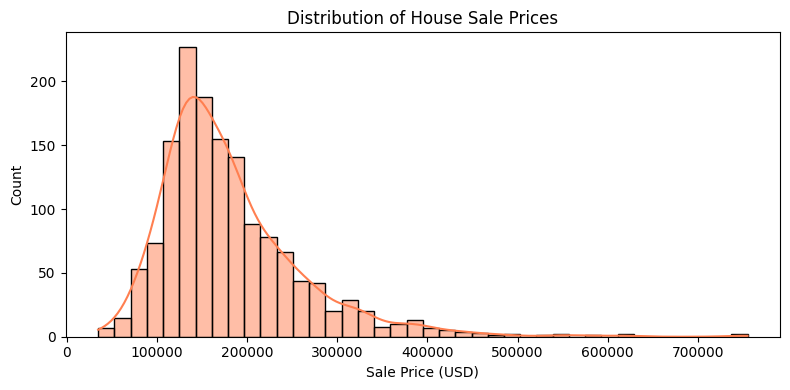

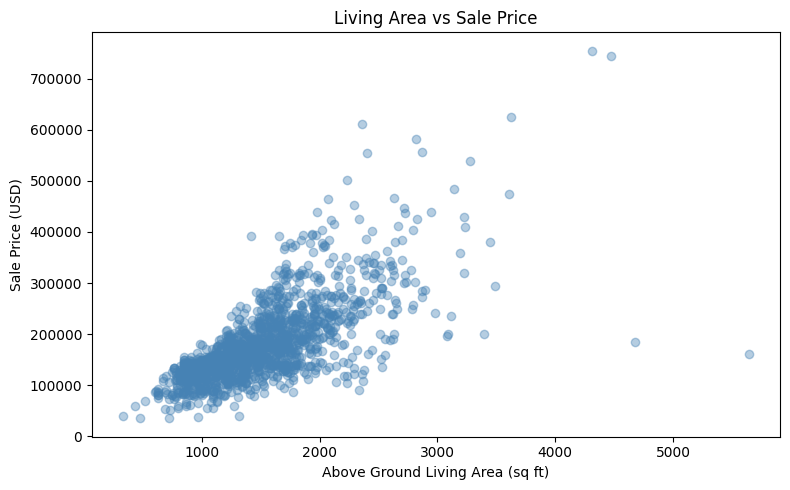

In [17]:
# Distribution of house prices
plt.figure(figsize=(8,4))
sns.histplot(df_model['SalePrice'], bins=40, kde=True, color='coral')
plt.title('Distribution of House Sale Prices')
plt.xlabel('Sale Price (USD)')
plt.tight_layout(); plt.show()
# Living area vs price
plt.figure(figsize=(8,5))
plt.scatter(df_model['GrLivArea'], df_model['SalePrice'],
            alpha=0.4, color='steelblue')
plt.xlabel('Above Ground Living Area (sq ft)')
plt.ylabel('Sale Price (USD)')
plt.title('Living Area vs Sale Price')
plt.tight_layout(); plt.show()

In [18]:
X = df_model[features]
y = df_model[target]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Gradient Boosting (more powerful than Linear Regression)
model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1,
                                   max_depth=4, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print('Model trained!')

Model trained!


In [19]:
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
print(f'Mean Absolute Error:  ${mae:,.0f}')
print(f'Root Mean Sq Error:   ${rmse:,.0f}')
print(f'R2 Score:             {r2:.4f}')

Mean Absolute Error:  $19,139
Root Mean Sq Error:   $28,810
R2 Score:             0.8918


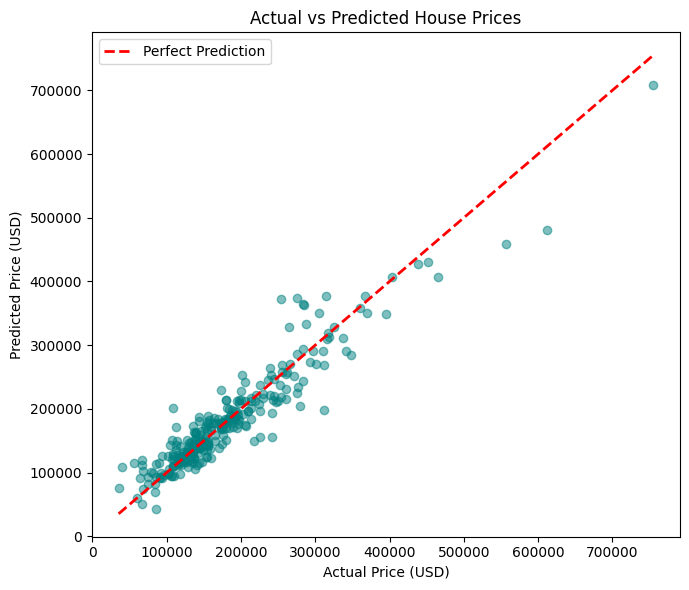

In [20]:
#  Plot Actual vs Predicted Prices
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()],
[y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Price (USD)')
plt.ylabel('Predicted Price (USD)')
plt.title('Actual vs Predicted House Prices')
plt.legend(); plt.tight_layout(); plt.show()

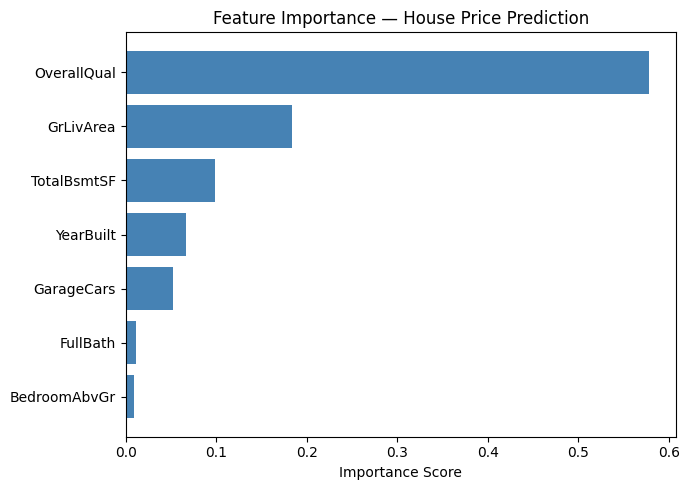

In [21]:
importances = model.feature_importances_
feat_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)
plt.figure(figsize=(7,5))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='steelblue')
plt.title('Feature Importance — House Price Prediction')
plt.xlabel('Importance Score')
plt.tight_layout(); plt.show()

# Task 6 Summary

## Objective
Predict house sale prices using machine learning.

## Dataset
House Prices – Advanced Regression Techniques (Kaggle)

## Model
Gradient Boosting Regressor

## Results
- Missing values handled successfully.
- Histogram showed most house prices are concentrated in the middle range.
- Living area has a strong positive relationship with sale price.
- The model achieved a good R² score, indicating accurate predictions.
- Feature importance showed OverallQual and GrLivArea were among the most influential features.